In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Sampler comparison — results

Loads `verification_experiments/results/sampler_comparison.csv` (produced by
`sampler_comparison.py`) and compares 11 pair-sampling strategies across three
families:

| Family | Strategies |
|---|---|
| **pair** | full batch · 10% · √C(n,2) · √n |
| **vertex** | k=1 · k=10 · k=n-1 |
| **node** | 5% · 10% · 25% · 50% of n nodes |

Key metric: `total_evals = evals_per_epoch × actual_epochs` — total gradient
evaluations until convergence (early stopping at `tol=1e-4`, `patience=5`).


In [30]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import binned_statistic


In [31]:
CSV_PATH = Path("verification_experiments/results/sampler_comparison.csv")

METHOD_ORDER = [
    "pair_full", "pair_frac10", "pair_sqrt_pairs", "pair_sqrt_n",
    "vertex_k1", "vertex_k10", "vertex_kN",
    "node_k_frac05", "node_k_frac10", "node_k_frac25", "node_k_frac50",
]
METHOD_LABELS = {
    "pair_full":       "pair (full)",
    "pair_frac10":     "pair (10%)",
    "pair_sqrt_pairs": "pair (√P)",
    "pair_sqrt_n":     "pair (√n)",
    "vertex_k1":       "vertex k=1",
    "vertex_k10":      "vertex k=10",
    "vertex_kN":       "vertex k=n−1",
    "node_k_frac05":   "node 5%",
    "node_k_frac10":   "node 10%",
    "node_k_frac25":   "node 25%",
    "node_k_frac50":   "node 50%",
}
METHOD_COLORS = {
    "pair_full":       "#08519C",
    "pair_frac10":     "#2171B5",
    "pair_sqrt_pairs": "#6BAED6",
    "pair_sqrt_n":     "#C6DBEF",
    "vertex_k1":       "#A63603",
    "vertex_k10":      "#E6550D",
    "vertex_kN":       "#FDAE6B",
    "node_k_frac05":   "#00441B",
    "node_k_frac10":   "#238B45",
    "node_k_frac25":   "#74C476",
    "node_k_frac50":   "#BAE4BC",
}
METHOD_MARKERS = {
    "pair_full": "o", "pair_frac10": "s",
    "pair_sqrt_pairs": "D", "pair_sqrt_n": "^",
    "vertex_k1": "o", "vertex_k10": "s", "vertex_kN": "D",
    "node_k_frac05": "o", "node_k_frac10": "s",
    "node_k_frac25": "D", "node_k_frac50": "^",
}
FAMILIES = {
    "pair":   ["pair_full", "pair_frac10", "pair_sqrt_pairs", "pair_sqrt_n"],
    "vertex": ["vertex_k1", "vertex_k10", "vertex_kN"],
    "node":   ["node_k_frac05", "node_k_frac10", "node_k_frac25", "node_k_frac50"],
}
FAMILY_COLORS = {"pair": "#2171B5", "vertex": "#E6550D", "node": "#238B45"}

METRICS = ["stress", "distortion", "sgs", "np_score"]
METRIC_LABELS = {
    "stress":     "Normalized stress  (↓)",
    "distortion": "Distortion  (↓)",
    "sgs":        "SGS — Spearman rank corr.  (↑)",
    "np_score":   "Neighbourhood preservation  (↑)",
}


In [32]:
df = pd.read_csv(CSV_PATH)
df["method"] = df["method"].str.strip()
df = df[df["method"].isin(METHOD_ORDER)].copy()

# actual_epochs may be absent in older CSVs; fall back to max across method
if "actual_epochs" not in df.columns:
    print("WARNING: 'actual_epochs' column missing — re-run sampler_comparison.py")
    df["actual_epochs"] = df.groupby("method")["t_embed"].transform(
        lambda x: x.notna().sum()  # dummy fallback
    )

df["total_evals"] = df["evals_per_epoch"] * df["actual_epochs"]
df["family"] = df["method"].map(
    {m: fam for fam, ms in FAMILIES.items() for m in ms}
)

methods_present = [m for m in METHOD_ORDER if m in df["method"].unique()]

print(f"Loaded {len(df):,} rows, {df['exp_idx'].nunique()} graph instances")
print(f"Methods ({len(methods_present)}):", methods_present)
print(f"n range: {df['n'].min()} – {df['n'].max()}")
print(f"actual_epochs range: {df['actual_epochs'].min():.0f} – {df['actual_epochs'].max():.0f}")
df.head(6)


Loaded 1,650 rows, 150 graph instances
Methods (11): ['pair_full', 'pair_frac10', 'pair_sqrt_pairs', 'pair_sqrt_n', 'vertex_k1', 'vertex_k10', 'vertex_kN', 'node_k_frac05', 'node_k_frac10', 'node_k_frac25', 'node_k_frac50']
n range: 50 – 295
actual_epochs range: 2560 – 5000


,exp_idx,n,epsilon,eps_actual,graph_type,t_spd,method,vertex_k,evals_per_epoch,actual_epochs,t_embed,alpha,stress,distortion,sgs,np_score,total_evals,family
0,0,156,0.28,0.28,toroidal,0.0114,pair_full,pair,4096,5000,3.3034,4.893413,0.158601,0.139256,0.876508,0.971473,20480000,pair
1,0,156,0.28,0.28,toroidal,0.0114,pair_frac10,pair,1209,5000,0.7288,4.895157,0.158636,0.139587,0.876104,0.969829,6045000,pair
2,0,156,0.28,0.28,toroidal,0.0114,pair_sqrt_pairs,pair,109,5000,0.1216,4.893586,0.159011,0.139546,0.876014,0.967961,545000,pair
3,0,156,0.28,0.28,toroidal,0.0114,pair_sqrt_n,pair,12,5000,0.0732,4.749137,0.252213,0.211140,0.713455,0.883357,60000,pair
4,0,156,0.28,0.28,toroidal,0.0114,vertex_k1,1,156,5000,1.9996,4.894587,0.158917,0.139283,0.876076,0.966853,780000,vertex
5,0,156,0.28,0.28,toroidal,0.0114,vertex_k10,10,1560,5000,2.6023,4.856359,0.198156,0.168210,0.810412,0.929024,7800000,vertex


## 1. Quality distributions by sampler

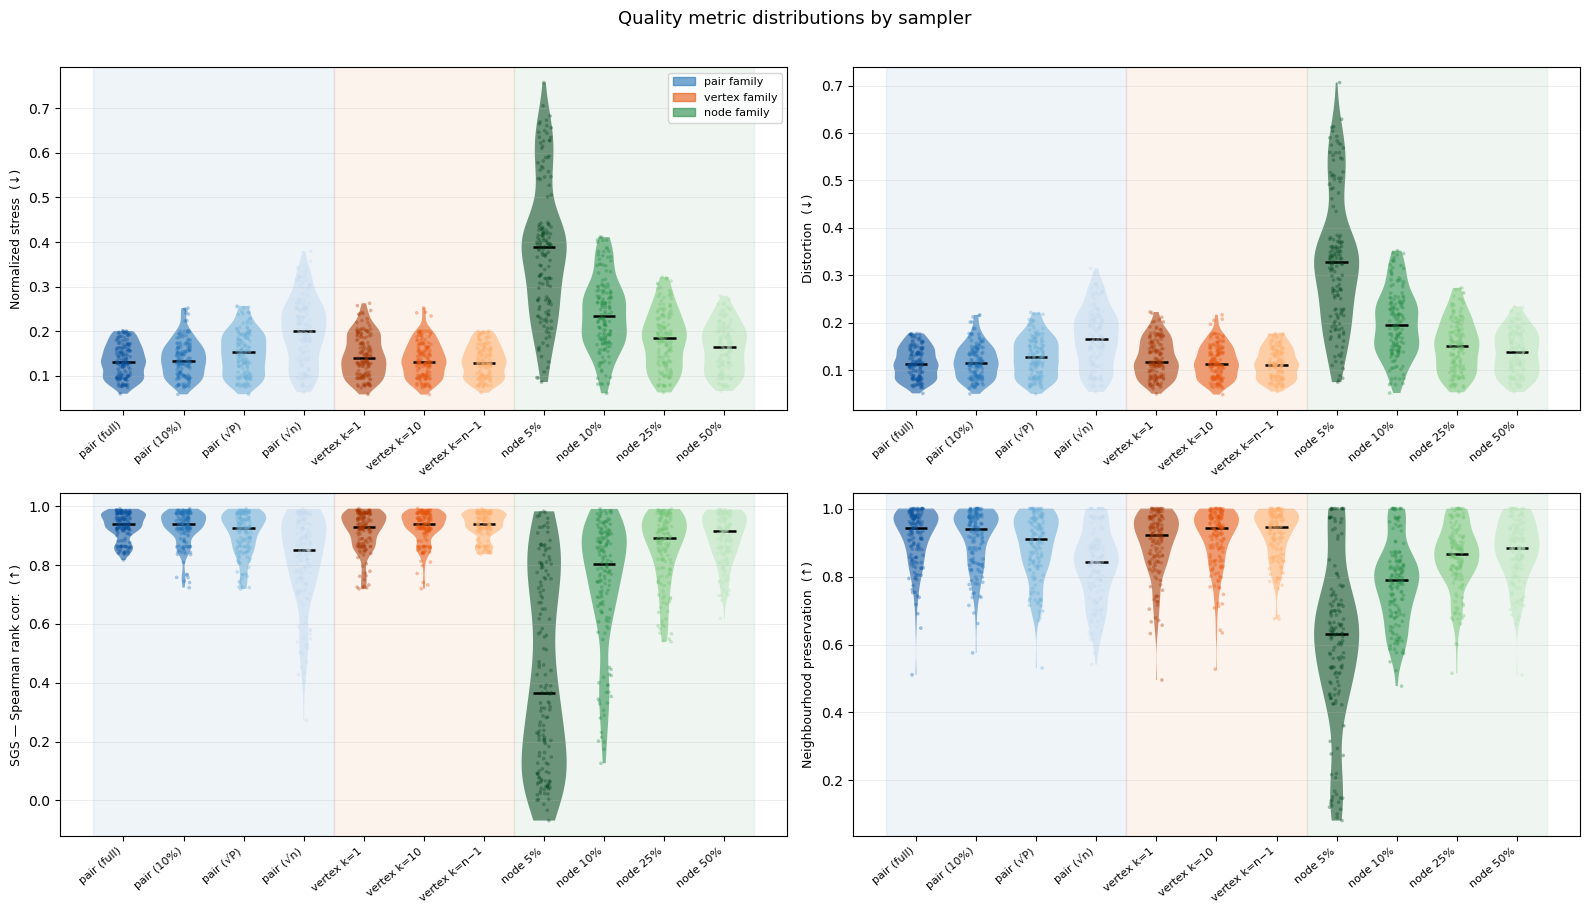

In [33]:
rng_j = np.random.default_rng(42)

# Compute family boundary positions for background bands
family_positions = {}
pos = 0
for fam, ms in FAMILIES.items():
    present = [m for m in ms if m in methods_present]
    if present:
        family_positions[fam] = (pos, pos + len(present))
        pos += len(present)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, metric in zip(axes.flat, METRICS):
    data_list = [df[df["method"] == m][metric].dropna().values for m in methods_present]

    parts = ax.violinplot(
        data_list, positions=range(len(methods_present)),
        widths=0.75, showmedians=True, showextrema=False,
    )
    for pc, m in zip(parts["bodies"], methods_present):
        pc.set_facecolor(METHOD_COLORS.get(m, "grey"))
        pc.set_alpha(0.55)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.8)

    # Jitter dots
    for xi, m in enumerate(methods_present):
        vals = df[df["method"] == m][metric].dropna().values
        jitter = rng_j.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(xi + jitter, vals, s=7, color=METHOD_COLORS.get(m, "grey"),
                   alpha=0.35, zorder=4, edgecolors="none")

    # Family background bands
    for fam, (x0, x1) in family_positions.items():
        ax.axvspan(x0 - 0.5, x1 - 0.5, alpha=0.07,
                   color=FAMILY_COLORS[fam], zorder=0)

    ax.set_xticks(range(len(methods_present)))
    ax.set_xticklabels(
        [METHOD_LABELS.get(m, m) for m in methods_present],
        rotation=40, ha="right", fontsize=8,
    )
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
    ax.grid(axis="y", lw=0.4, alpha=0.4)

# Family legend
legend_patches = [
    mpatches.Patch(color=FAMILY_COLORS[f], alpha=0.6, label=f"{f} family")
    for f in FAMILIES
]
axes.flat[0].legend(handles=legend_patches, fontsize=8, loc="upper right")

fig.suptitle("Quality metric distributions by sampler", fontsize=13, y=1.01)
fig.tight_layout()
plt.savefig("verification_experiments/results/sampler_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Quality vs graph size *n*

Binned median lines per method (bins of ~20 observations).


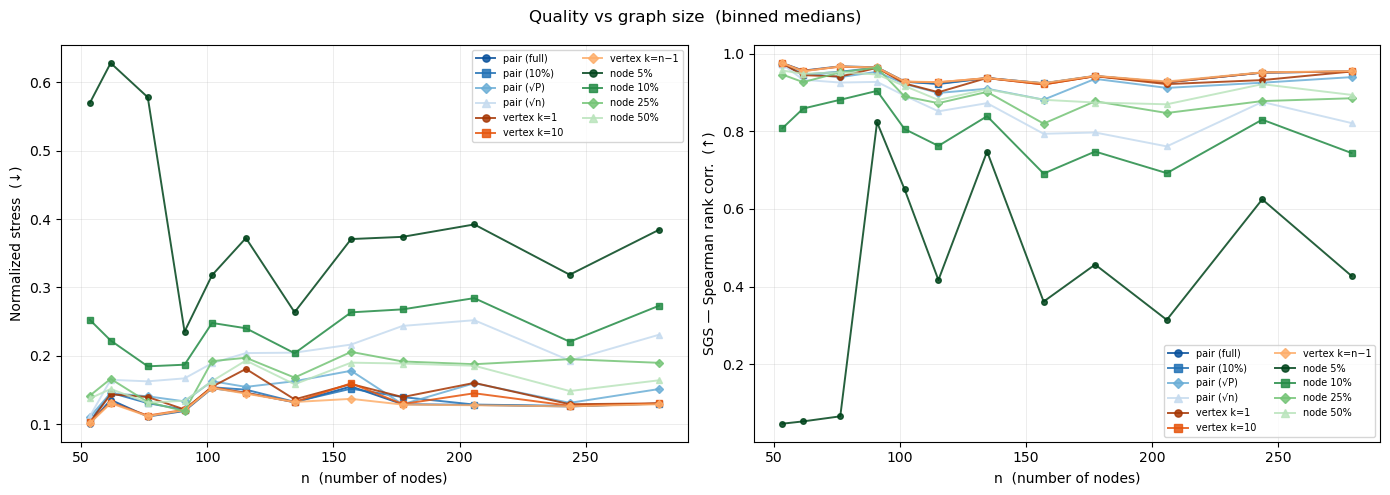

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_bins = 12

for ax, metric in zip(axes, ["stress", "sgs"]):
    for m in methods_present:
        sub = df[df["method"] == m].dropna(subset=["n", metric])
        if len(sub) < 5:
            continue
        bins = np.percentile(sub["n"], np.linspace(0, 100, n_bins + 1))
        bins = np.unique(bins)
        medians, edges, _ = binned_statistic(sub["n"], sub[metric],
                                              statistic="median", bins=bins)
        counts, _, _      = binned_statistic(sub["n"], sub[metric],
                                              statistic="count",  bins=bins)
        centers = 0.5 * (edges[:-1] + edges[1:])
        mask = counts >= 3
        ax.plot(centers[mask], medians[mask],
                color=METHOD_COLORS.get(m, "grey"),
                marker=METHOD_MARKERS.get(m, "o"), markersize=4,
                linewidth=1.4, alpha=0.85,
                label=METHOD_LABELS.get(m, m))

    ax.set_xlabel("n  (number of nodes)")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.legend(ncol=2, fontsize=7, markerscale=1.3)
    ax.grid(True, lw=0.4, alpha=0.4)

fig.suptitle("Quality vs graph size  (binned medians)", fontsize=12)
fig.tight_layout()
plt.savefig("verification_experiments/results/sampler_quality_vs_n.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Efficiency — quality vs total gradient evaluations

`total_evals = evals_per_epoch × actual_epochs` is the total computational
budget until early-stopping convergence.  Strategies in the **lower-left** of
this plot are preferred: low cost *and* low stress.


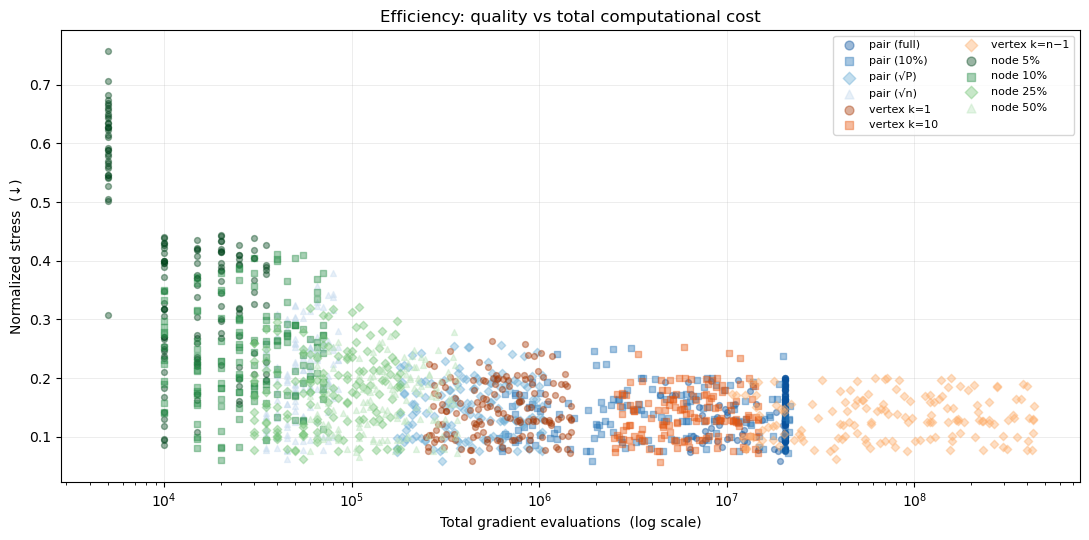

In [35]:
fig, ax = plt.subplots(figsize=(11, 5.5))

for m in methods_present:
    sub = df[df["method"] == m].dropna(subset=["total_evals", "stress"])
    ax.scatter(
        sub["total_evals"], sub["stress"],
        color=METHOD_COLORS.get(m, "grey"),
        marker=METHOD_MARKERS.get(m, "o"),
        alpha=0.4, s=18, zorder=3,
        label=METHOD_LABELS.get(m, m),
    )

ax.set_xscale("log")
ax.set_xlabel("Total gradient evaluations  (log scale)", fontsize=10)
ax.set_ylabel("Normalized stress  (↓)", fontsize=10)
ax.set_title("Efficiency: quality vs total computational cost", fontsize=12)
ax.legend(ncol=2, fontsize=8, markerscale=1.5)
ax.grid(True, lw=0.4, alpha=0.4)
fig.tight_layout()
plt.savefig("verification_experiments/results/sampler_efficiency_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Efficiency curves by family  (binned medians)

Each curve shows the median stress achieved across all graph instances that
had approximately the same total evaluation budget.  Better strategies
reach lower stress at the same x-position.


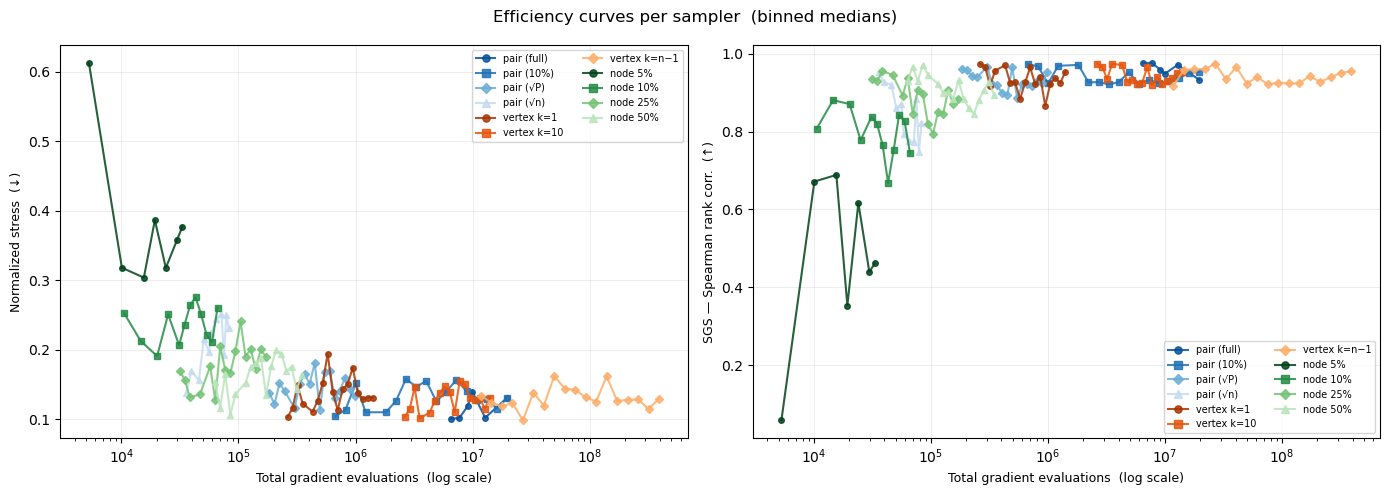

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_bins = 18
min_count = 4

for ax, metric in zip(axes, ["stress", "sgs"]):
    for m in methods_present:
        sub = df[df["method"] == m].dropna(subset=["total_evals", metric])
        if len(sub) < min_count:
            continue
        log_x = np.log10(sub["total_evals"].values)
        y     = sub[metric].values
        lo, hi = log_x.min(), log_x.max()
        if hi <= lo:
            continue
        bins = np.linspace(lo, hi, n_bins + 1)
        meds, edges, _ = binned_statistic(log_x, y, statistic="median", bins=bins)
        cnts, _,     _ = binned_statistic(log_x, y, statistic="count",  bins=bins)
        centers = 0.5 * (edges[:-1] + edges[1:])
        mask = cnts >= min_count
        ax.plot(10 ** centers[mask], meds[mask],
                color=METHOD_COLORS.get(m, "grey"),
                marker=METHOD_MARKERS.get(m, "o"), markersize=4,
                linewidth=1.5, alpha=0.85,
                label=METHOD_LABELS.get(m, m))

    ax.set_xscale("log")
    ax.set_xlabel("Total gradient evaluations  (log scale)", fontsize=9)
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
    ax.legend(ncol=2, fontsize=7, markerscale=1.3)
    ax.grid(True, lw=0.4, alpha=0.4)

fig.suptitle("Efficiency curves per sampler  (binned medians)", fontsize=12)
fig.tight_layout()
plt.savefig("verification_experiments/results/sampler_efficiency_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 4b. Family-level summary

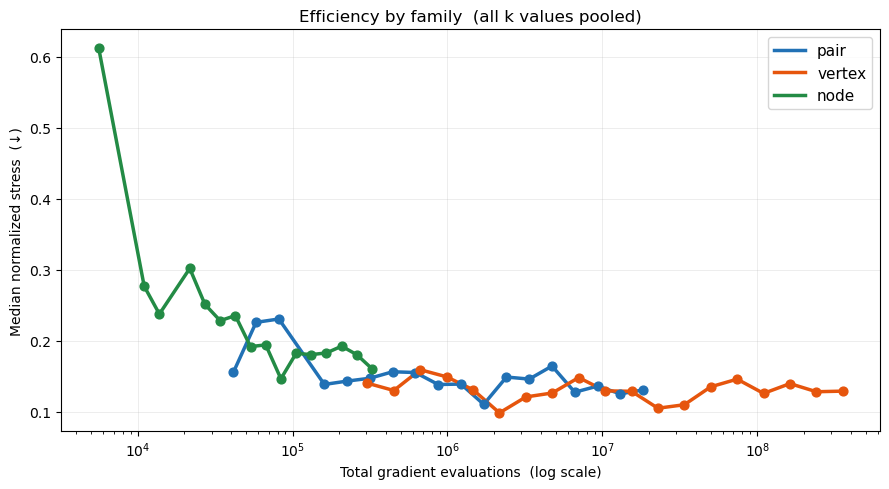

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
min_count = 4

for fam, ms in FAMILIES.items():
    sub = df[df["method"].isin(ms)].dropna(subset=["total_evals", "stress"])
    if len(sub) < min_count:
        continue
    log_x = np.log10(sub["total_evals"].values)
    lo, hi = log_x.min(), log_x.max()
    bins = np.linspace(lo, hi, 20)
    meds, edges, _ = binned_statistic(log_x, sub["stress"].values, "median", bins=bins)
    cnts, _,     _ = binned_statistic(log_x, sub["stress"].values, "count",  bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    mask = cnts >= min_count
    ax.plot(10 ** centers[mask], meds[mask],
            color=FAMILY_COLORS[fam], linewidth=2.5, label=fam)
    ax.scatter(10 ** centers[mask], meds[mask],
               color=FAMILY_COLORS[fam], s=40, zorder=5)

ax.set_xscale("log")
ax.set_xlabel("Total gradient evaluations  (log scale)", fontsize=10)
ax.set_ylabel("Median normalized stress  (↓)", fontsize=10)
ax.set_title("Efficiency by family  (all k values pooled)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, lw=0.4, alpha=0.4)
fig.tight_layout()
plt.savefig("verification_experiments/results/sampler_efficiency_by_family.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Wall-clock time

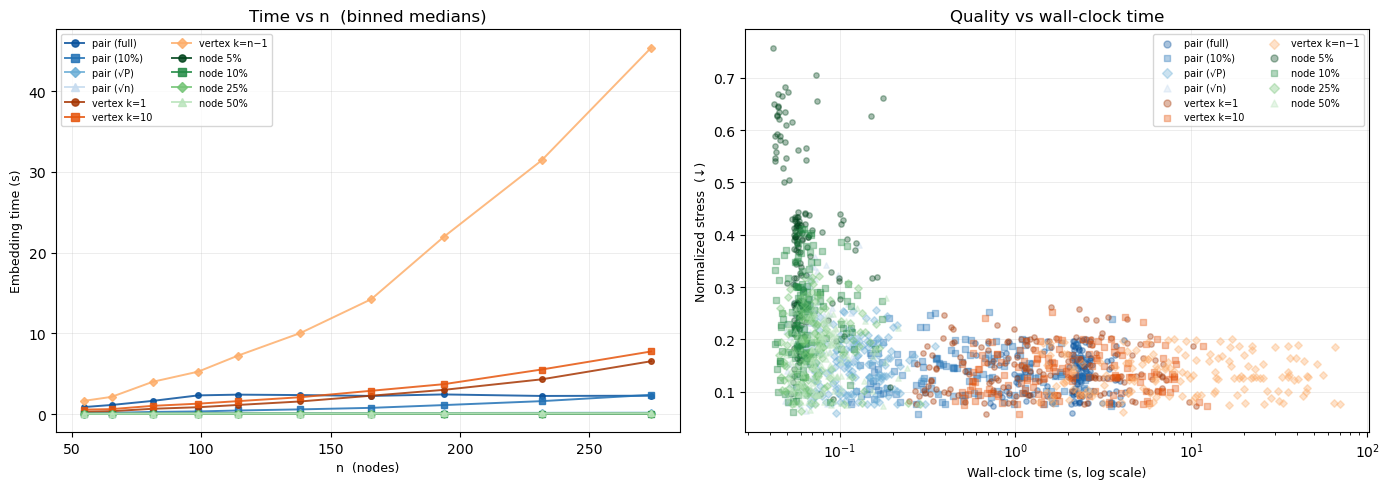

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: t_embed vs n (scatter + binned median)
ax = axes[0]
n_bins = 10
for m in methods_present:
    sub = df[df["method"] == m].dropna(subset=["n", "t_embed"])
    if len(sub) < 5:
        continue
    bins = np.percentile(sub["n"], np.linspace(0, 100, n_bins + 1))
    bins = np.unique(bins)
    meds, edges, _ = binned_statistic(sub["n"], sub["t_embed"], "median", bins=bins)
    cnts, _,     _ = binned_statistic(sub["n"], sub["t_embed"], "count",  bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    mask = cnts >= 3
    ax.plot(centers[mask], meds[mask],
            color=METHOD_COLORS.get(m, "grey"),
            marker=METHOD_MARKERS.get(m, "o"), markersize=4,
            linewidth=1.4, alpha=0.85,
            label=METHOD_LABELS.get(m, m))
ax.set_xlabel("n  (nodes)", fontsize=9)
ax.set_ylabel("Embedding time (s)", fontsize=9)
ax.set_title("Time vs n  (binned medians)")
ax.legend(ncol=2, fontsize=7, markerscale=1.3)
ax.grid(True, lw=0.4, alpha=0.4)

# Right: stress vs t_embed (efficiency in wall-clock terms)
ax = axes[1]
for m in methods_present:
    sub = df[df["method"] == m].dropna(subset=["t_embed", "stress"])
    ax.scatter(sub["t_embed"], sub["stress"],
               color=METHOD_COLORS.get(m, "grey"),
               marker=METHOD_MARKERS.get(m, "o"),
               alpha=0.35, s=15, zorder=3,
               label=METHOD_LABELS.get(m, m))
ax.set_xscale("log")
ax.set_xlabel("Wall-clock time (s, log scale)", fontsize=9)
ax.set_ylabel("Normalized stress  (↓)", fontsize=9)
ax.set_title("Quality vs wall-clock time")
ax.legend(ncol=2, fontsize=7, markerscale=1.3)
ax.grid(True, lw=0.4, alpha=0.4)

fig.tight_layout()
plt.savefig("verification_experiments/results/sampler_timing.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Euclidean vs toroidal GRGs

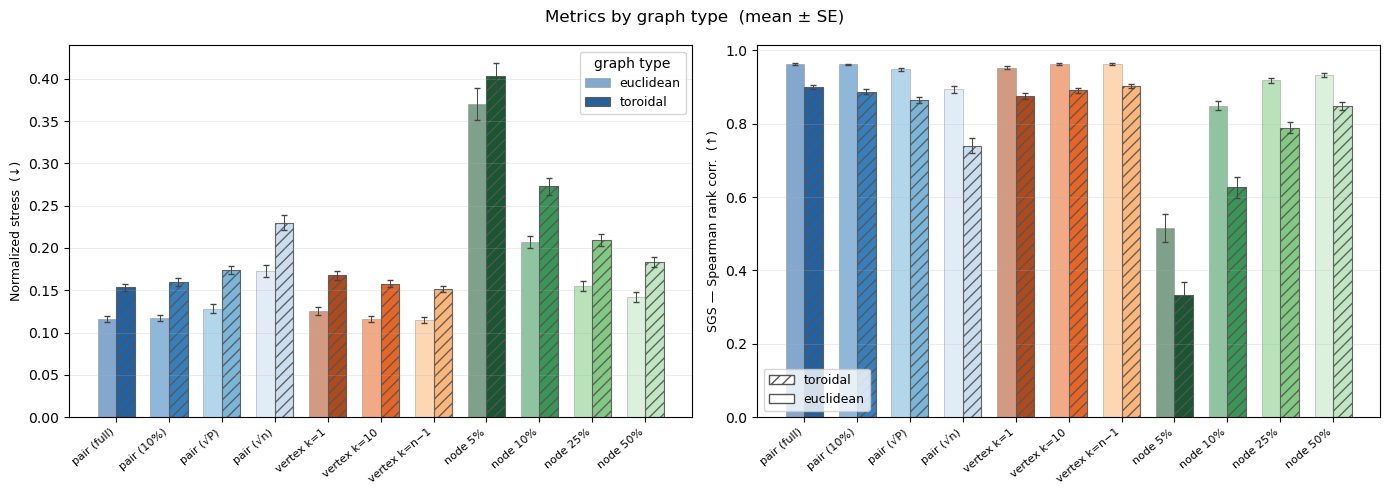

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
graph_types = ["euclidean", "toroidal"]
gt_alpha    = {"euclidean": 0.5, "toroidal": 0.9}
gt_hatch    = {"euclidean": "", "toroidal": "///"}
gt_lw       = {"euclidean": 0.4, "toroidal": 0.8}

positions = np.arange(len(methods_present))
bar_w = 0.35

for ax, metric in zip(axes, ["stress", "sgs"]):
    for gi, gt in enumerate(graph_types):
        sub_gt = df[df["graph_type"] == gt]
        means = [sub_gt[sub_gt["method"] == m][metric].mean() for m in methods_present]
        sems  = [sub_gt[sub_gt["method"] == m][metric].sem()  for m in methods_present]
        x_off = positions + (gi - 0.5) * bar_w
        ax.bar(x_off, means, width=bar_w,
               color=[METHOD_COLORS.get(m, "grey") for m in methods_present],
               alpha=gt_alpha[gt], hatch=gt_hatch[gt],
               edgecolor="#555", linewidth=gt_lw[gt],
               yerr=sems, capsize=2,
               error_kw=dict(elinewidth=0.7, ecolor="#444"),
               label=gt)

    ax.set_xticks(positions)
    ax.set_xticklabels([METHOD_LABELS.get(m, m) for m in methods_present],
                        rotation=40, ha="right", fontsize=8)
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=9)
    ax.grid(axis="y", lw=0.4, alpha=0.4)

axes[0].legend(fontsize=9, title="graph type")
legend_patches = [
    mpatches.Patch(facecolor="white", edgecolor="#555", hatch="///", label="toroidal"),
    mpatches.Patch(facecolor="white", edgecolor="#555", label="euclidean"),
]
axes[1].legend(handles=legend_patches, fontsize=9)

fig.suptitle("Metrics by graph type  (mean ± SE)", fontsize=12)
fig.tight_layout()
plt.savefig("verification_experiments/results/sampler_by_graph_type.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Summary statistics by method

In [40]:
summary = (
    df[df["method"].isin(methods_present)]
    .groupby("method")[METRICS + ["t_embed", "total_evals", "actual_epochs"]]
    .agg(["median", "mean", "std"])
)
summary.columns = ["_".join(c) for c in summary.columns]
summary.index   = [METHOD_LABELS.get(m, m) for m in summary.index]
# Reorder rows to match METHOD_ORDER
order_map = {METHOD_LABELS.get(m, m): i for i, m in enumerate(methods_present)}
summary = summary.loc[sorted(summary.index, key=lambda x: order_map.get(x, 99))]
summary.round(4)


,stress_median,stress_mean,stress_std,distortion_median,distortion_mean,distortion_std,sgs_median,sgs_mean,sgs_std,np_score_median,...,np_score_std,t_embed_median,t_embed_mean,t_embed_std,total_evals_median,total_evals_mean,total_evals_std,actual_epochs_median,actual_epochs_mean,actual_epochs_std
pair (full),0.1298,0.1337,0.0370,0.1120,0.1155,0.0326,0.9410,0.9324,0.0461,0.9427,...,0.0828,2.2678,2.2024,0.7883,20480000.0,1.753156e+07,5.155834e+06,5000.0,4895.36,431.4702
pair (10%),0.1324,0.1376,0.0415,0.1144,0.1185,0.0358,0.9388,0.9261,0.0579,0.9408,...,0.0836,0.5324,0.8361,0.7681,3720000.0,6.241867e+06,5.931551e+06,5000.0,5000.00,0.0000
pair (√P),0.1520,0.1504,0.0487,0.1266,0.1283,0.0414,0.9263,0.9077,0.0716,0.9094,...,0.0937,0.1194,0.1331,0.0545,430000.0,4.962000e+05,2.523292e+05,5000.0,5000.00,0.0000
pair (√n),0.2003,0.2003,0.0740,0.1648,0.1668,0.0620,0.8522,0.8198,0.1517,0.8417,...,0.1076,0.0676,0.0722,0.0188,55000.0,5.523333e+04,1.486332e+04,5000.0,5000.00,0.0000
vertex k=1,0.1398,0.1457,0.0471,0.1174,0.1247,0.0401,0.9281,0.9149,0.0672,0.9226,...,0.0919,1.2966,2.2399,2.1670,612500.0,7.080667e+05,3.569195e+05,5000.0,5000.00,0.0000
vertex k=10,0.1308,0.1362,0.0402,0.1130,0.1175,0.0350,0.9395,0.9280,0.0554,0.9420,...,0.0858,1.8815,2.8874,2.4849,6125000.0,7.080667e+06,3.569195e+06,5000.0,5000.00,0.0000
vertex k=n−1,0.1287,0.1324,0.0364,0.1116,0.1145,0.0322,0.9413,0.9340,0.0445,0.9467,...,0.0725,8.8340,14.9634,15.0201,74430000.0,1.246252e+08,1.188470e+08,5000.0,4940.64,263.9101
node 5%,0.3897,0.3857,0.1528,0.3271,0.3314,0.1410,0.3640,0.4275,0.3260,0.6296,...,0.2427,0.0576,0.0646,0.0247,15000.0,1.523333e+04,9.110372e+03,5000.0,5000.00,0.0000
node 10%,0.2330,0.2388,0.0825,0.1958,0.1989,0.0710,0.8027,0.7424,0.2141,0.7885,...,0.1222,0.0614,0.0676,0.0230,30000.0,3.290000e+04,1.792293e+04,5000.0,5000.00,0.0000
node 25%,0.1839,0.1813,0.0651,0.1503,0.1512,0.0548,0.8922,0.8564,0.1193,0.8660,...,0.0954,0.0692,0.0770,0.0322,75000.0,8.623333e+04,4.467232e+04,5000.0,5000.00,0.0000


## 8. Statistical tests

Since each method runs on the **same** graph instances, observations are paired.

1. **Friedman omnibus test** across all methods.
2. **Pairwise Wilcoxon signed-rank** for every method pair, Holm–Bonferroni corrected.


In [41]:
pivot = (
    df[df["method"].isin(methods_present)]
    .pivot_table(index="exp_idx", columns="method", values="stress")
    .dropna()
)
n_complete = len(pivot)
n_total    = df["exp_idx"].nunique()
print(f"Complete cases (all methods present): {n_complete} / {n_total}")

methods_in_pivot = [m for m in methods_present if m in pivot.columns]
groups = [pivot[m].values for m in methods_in_pivot]

chi2, p_friedman = stats.friedmanchisquare(*groups)
df_f = len(methods_in_pivot) - 1
print(f"\nFriedman test: χ²({df_f}) = {chi2:.3f},  p = {p_friedman:.2e}")
if p_friedman < 0.05:
    print("→ At least one method differs significantly (α = 0.05)")
else:
    print("→ No significant difference detected (α = 0.05)")


Complete cases (all methods present): 150 / 150

Friedman test: χ²(10) = 1125.325,  p = 1.83e-235
→ At least one method differs significantly (α = 0.05)


In [42]:
pairs_list = list(combinations(methods_in_pivot, 2))
n_tests    = len(pairs_list)

rows = []
for ma, mb in pairs_list:
    a, b = pivot[ma].values, pivot[mb].values
    W, p_raw = stats.wilcoxon(a, b, alternative="two-sided")
    med_diff = float(np.median(a - b))
    rows.append({
        "A":                METHOD_LABELS.get(ma, ma),
        "B":                METHOD_LABELS.get(mb, mb),
        "med(A)":           round(pivot[ma].median(), 4),
        "med(B)":           round(pivot[mb].median(), 4),
        "med diff (A−B)":   round(med_diff, 4),
        "W":                int(W),
        "p_raw":            p_raw,
    })

df_pw = pd.DataFrame(rows).sort_values("p_raw").reset_index(drop=True)

# Holm–Bonferroni correction
p_holm = [(n_tests - i) * row["p_raw"] for i, row in df_pw.iterrows()]
for i in range(1, len(p_holm)):
    p_holm[i] = max(p_holm[i], p_holm[i - 1])
df_pw["p_holm"] = [min(1.0, p) for p in p_holm]
df_pw["sig"]    = df_pw["p_holm"] < 0.05

(
    df_pw.style
    .format({
        "med(A)":         "{:.4f}",
        "med(B)":         "{:.4f}",
        "med diff (A−B)": "{:+.4f}",
        "p_raw":          "{:.3e}",
        "p_holm":         "{:.3e}",
    })
    .apply(lambda col: [
        "background-color: #c6efce" if v else "" for v in df_pw["sig"]
    ], subset=["p_holm", "sig"])
    .set_caption(
        f"Pairwise Wilcoxon signed-rank (n={n_complete} paired graphs), "
        "Holm-corrected — green = significant at α=0.05"
    )
)


,A,B,med(A),med(B),med diff (A−B),W,p_raw,p_holm,sig
0,pair (full),node 5%,0.1298,0.3897,-0.2335,0,2.300e-26,1.265e-24,True
1,node 5%,node 25%,0.3897,0.1839,+0.1526,0,2.300e-26,1.265e-24,True
2,vertex k=10,node 5%,0.1308,0.3897,-0.2273,0,2.300e-26,1.265e-24,True
3,vertex k=n−1,node 5%,0.1287,0.3897,-0.2338,0,2.300e-26,1.265e-24,True
4,vertex k=1,node 5%,0.1398,0.3897,-0.2136,3,2.443e-26,1.265e-24,True
5,pair (10%),node 5%,0.1324,0.3897,-0.2273,3,2.443e-26,1.265e-24,True
6,pair (√P),node 5%,0.1520,0.3897,-0.2080,3,2.443e-26,1.265e-24,True
7,node 5%,node 50%,0.3897,0.1638,+0.1958,10,2.811e-26,1.349e-24,True
8,pair (full),node 10%,0.1298,0.2330,-0.1097,12,2.926e-26,1.375e-24,True
9,vertex k=n−1,node 10%,0.1287,0.2330,-0.1099,13,2.986e-26,1.375e-24,True
